In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make charts look nice
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" Libraries loaded!")

 Libraries loaded!


In [5]:
# Load all datasets
netflix = pd.read_csv('../data/netflix_titles.csv')
trending = pd.read_csv('../data/tmdb_trending.csv')
movies   = pd.read_csv('../data/tmdb_movies.csv')
tv       = pd.read_csv('../data/tmdb_tv.csv')

# Quick check
print("Netflix shape:", netflix.shape)
print("Trending shape:", trending.shape)
print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

Netflix shape: (8807, 12)
Trending shape: (99, 20)
Movies shape: (200, 15)
TV shape: (200, 15)


In [6]:
# See first 5 rows
print(netflix.head())

# See all column names
print("\nColumns:", netflix.columns.tolist())

# Check missing values
print("\nMissing values:")
print(netflix.isnull().sum())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [7]:
#  Drop rows where title or type is missing
netflix.dropna(subset=['title', 'type'], inplace=True)

#  Fill missing values
netflix['country'].fillna('Unknown', inplace=True)
netflix['rating'].fillna('Not Rated', inplace=True)
netflix['director'].fillna('Unknown', inplace=True)
netflix['cast'].fillna('Unknown', inplace=True)
netflix['duration'].fillna('Unknown', inplace=True)

# 3. Fix date column
netflix['date_added'] = pd.to_datetime(
    netflix['date_added'].str.strip(), errors='coerce'
)
netflix['year_added']  = netflix['date_added'].dt.year
netflix['month_added'] = netflix['date_added'].dt.month

# 4. Fix release year
netflix['release_year'] = pd.to_numeric(
    netflix['release_year'], errors='coerce'
)

# Confirm it's clean
print("Missing values after cleaning:")
print(netflix.isnull().sum())
print(f"\n Clean dataset: {netflix.shape[0]} rows")

Missing values after cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64

 Clean dataset: 8807 rows


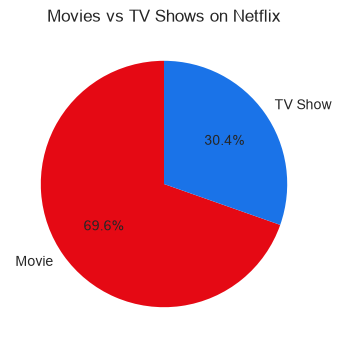

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [8]:
type_counts = netflix['type'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(type_counts, labels=type_counts.index,
        autopct='%1.1f%%', colors=['#E50914','#1A73E8'],
        startangle=90)
plt.title('Movies vs TV Shows on Netflix')
plt.savefig('../data/movies_vs_tv.png', bbox_inches='tight')
plt.show()
print(type_counts)

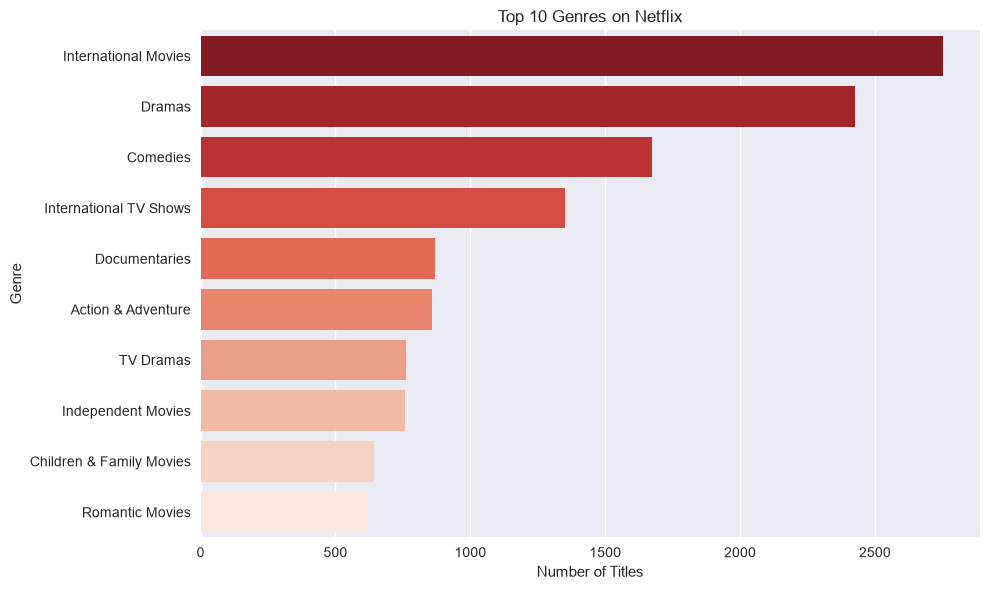

In [9]:
genres = netflix['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10).reset_index()
top_genres.columns = ['Genre', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_genres, x='Count', y='Genre', palette='Reds_r')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.tight_layout()
plt.savefig('../data/top_genres.png', bbox_inches='tight')
plt.show()

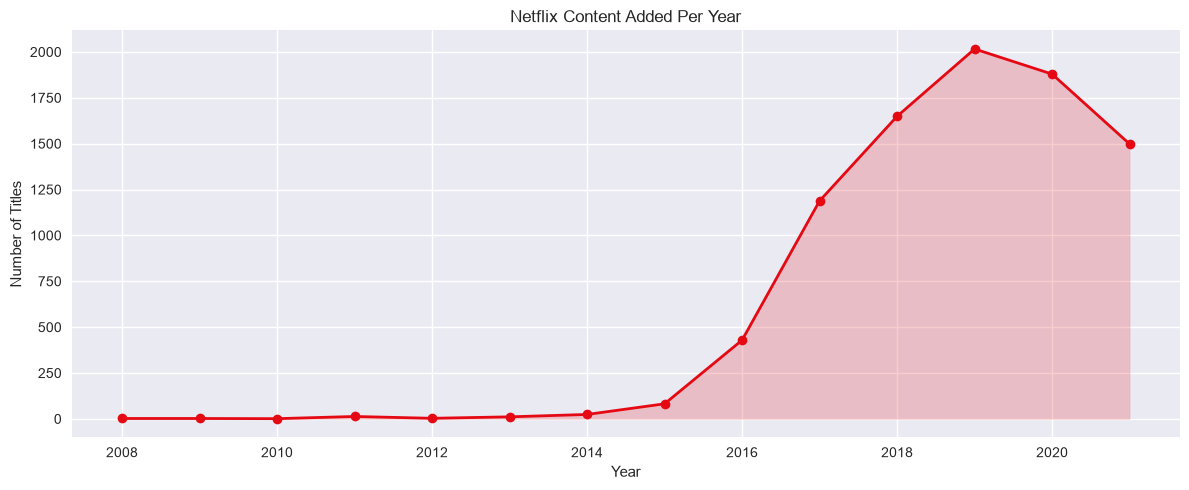

In [15]:
yearly = netflix.groupby('year_added').size().reset_index()
yearly.columns = ['Year', 'Titles Added']
yearly = yearly.dropna()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Titles Added'],
         marker='o', color='#E50914', linewidth=2)
plt.fill_between(yearly['Year'], yearly['Titles Added'],
                 alpha=0.2, color='#E50914')
plt.title('Netflix Content Added Per Year')
plt.ylabel('Number of Titles')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('../data/yearly_growth.png', bbox_inches='tight')
plt.show()

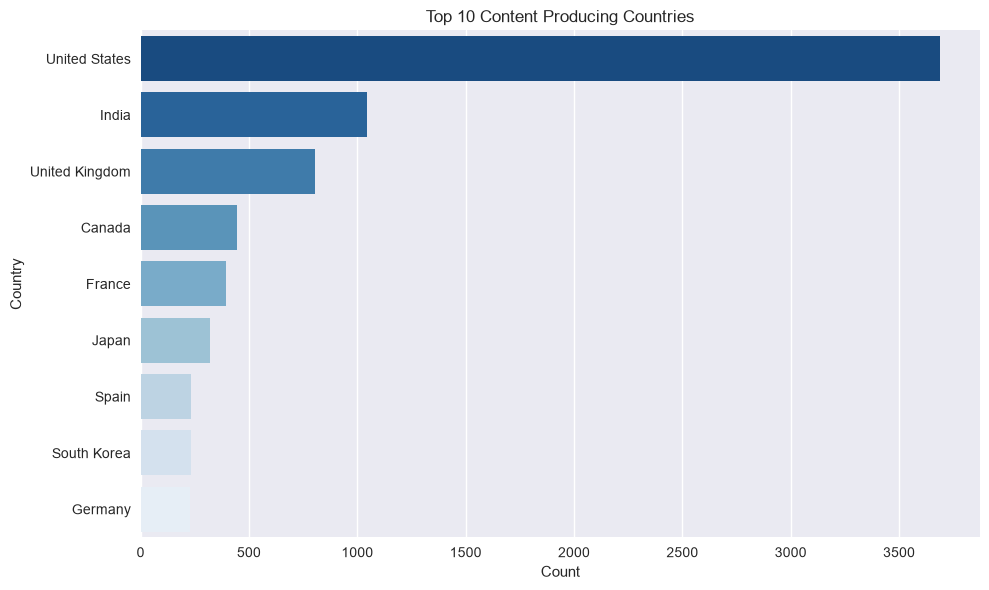

In [12]:
countries = netflix['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Count']
top_countries = top_countries[top_countries['Country'] != 'Unknown']

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x='Count', y='Country', palette='Blues_r')
plt.title('Top 10 Content Producing Countries')
plt.tight_layout()
plt.savefig('../data/top_countries.png', bbox_inches='tight')
plt.show()

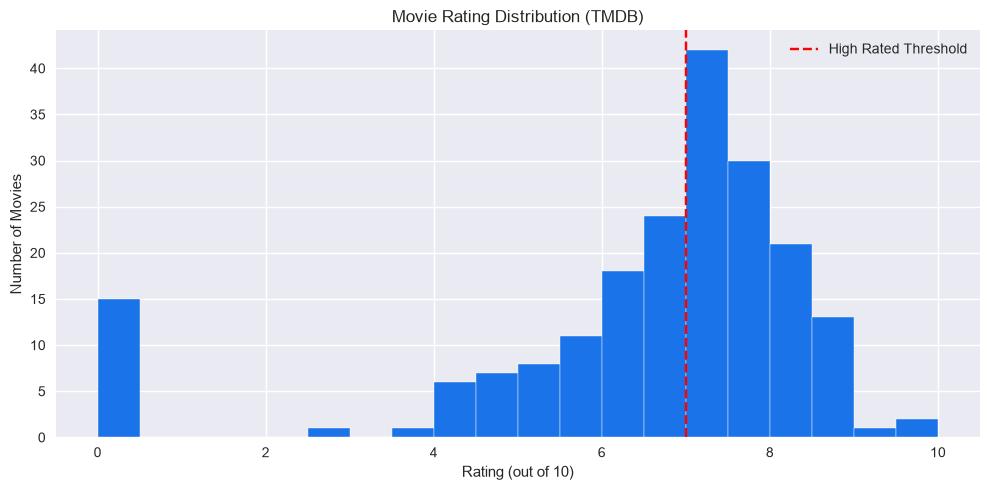

Average rating: 6.46


In [13]:
plt.figure(figsize=(10, 5))
plt.hist(movies['vote_average'].dropna(), bins=20,
         color='#1A73E8', edgecolor='white')
plt.title('Movie Rating Distribution (TMDB)')
plt.xlabel('Rating (out of 10)')
plt.ylabel('Number of Movies')
plt.axvline(x=7, color='red', linestyle='--', label='High Rated Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../data/rating_distribution.png', bbox_inches='tight')
plt.show()
print(f"Average rating: {movies['vote_average'].mean():.2f}")

In [16]:
# Save cleaned netflix dataset
netflix.to_csv('../data/netflix_clean.csv', index=False)
print(" Saved netflix_clean.csv")

# Save top genres for dashboard
top_genres.to_csv('../data/top_genres.csv', index=False)
print(" Saved top_genres.csv")

# Save yearly data for dashboard
yearly.to_csv('../data/yearly_growth.csv', index=False)
print(" Saved yearly_growth.csv")

print("\n Phase 3 Complete!")

 Saved netflix_clean.csv
 Saved top_genres.csv
 Saved yearly_growth.csv

 Phase 3 Complete!
